In [7]:
# === Core Python Utilities ===
import os
import re
import math
import random
import warnings
from datetime import datetime
from itertools import combinations
from collections import Counter
from typing import List, Tuple, Dict, Optional

# === Scientific Computing ===
import numpy as np
import pandas as pd
import scipy
from scipy.stats import skew

# === Visualization ===
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

# === Progress & Optimization ===
from tqdm.notebook import tqdm
tqdm.pandas()
import optuna

In [8]:
# Một số setting cơ bản
import warnings
import pandas as pd
warnings.filterwarnings ('ignore')
pd.set_option ('display.width', None)
pd.set_option ('display.max_rows', 100)
pd.set_option ('display.max_columns', 50)

# 1. Data

In [9]:
file_path = '/Users/kittnguyen/Documents/us-flight-project/data/silver_data/'
X_train = np.load(f"/kaggle/input/cleandata/X_train.npy", allow_pickle=True)
y_train = np.load(f"/kaggle/input/cleandata/y_train.npy", allow_pickle=True)
X_dev = np.load(f"/kaggle/input/cleandata/X_dev.npy", allow_pickle=True)
y_dev = np.load(f"/kaggle/input/cleandata/y_dev.npy", allow_pickle=True)
X_test = np.load(f"/kaggle/input/cleandata/X_test.npy", allow_pickle=True)
y_test = np.load(f"/kaggle/input/cleandata/y_test.npy", allow_pickle=True)

In [10]:
timesteps = 1
X_train = X_train.reshape(X_train.shape[0], timesteps, X_train.shape[1])
X_dev = X_dev.reshape(X_dev.shape[0], timesteps, X_dev.shape[1])
X_test = X_test.reshape(X_test.shape[0], timesteps, X_test.shape[1])

# 2. BiLSTM Model

In [27]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class BiLSTMModel(nn.Module):
    def __init__(self, input_size, hidden_dim1=128, hidden_dim2=64, fc_dim=16, dropout_rates=(0.4, 0.4, 0.3)):
        super(BiLSTMModel, self).__init__()
        # BiLSTM đầu tiên (2 chiều)
        self.bilstm1 = nn.LSTM(input_size=input_size, hidden_size=hidden_dim1, batch_first=True, bidirectional=True)
        self.dropout1 = nn.Dropout(dropout_rates[0])
        
        # BiLSTM thứ 2 (2 chiều)
        # Lưu ý: input_size của LSTM thứ 2 phải là hidden_dim1 * 2 vì bidirectional
        self.bilstm2 = nn.LSTM(input_size=hidden_dim1*2, hidden_size=hidden_dim2, batch_first=True, bidirectional=True)
        self.dropout2 = nn.Dropout(dropout_rates[1])
        
        # Fully connected layers
        # input cho fc phải là hidden_dim2 * 2 do BiLSTM thứ 2 2 chiều
        self.fc1 = nn.Linear(hidden_dim2 * 2, fc_dim)
        self.dropout3 = nn.Dropout(dropout_rates[2])
        
        self.out = nn.Linear(fc_dim, 1)
    
    def forward(self, x):
        # x: (batch_size, seq_len, input_size)
        lstm_out1, _ = self.bilstm1(x)  # (batch_size, seq_len, hidden_dim1 * 2)
        lstm_out1 = self.dropout1(lstm_out1)
        
        lstm_out2, _ = self.bilstm2(lstm_out1)  # (batch_size, seq_len, hidden_dim2 * 2)
        lstm_out2 = self.dropout2(lstm_out2)
        
        # Lấy output timestep cuối cùng
        last_time_step = lstm_out2[:, -1, :]  # (batch_size, hidden_dim2 * 2)
        
        fc1_out = F.relu(self.fc1(last_time_step))
        fc1_out = self.dropout3(fc1_out)
        
        # out = torch.sigmoid(self.out(fc1_out))
        out = self.out(fc1_out)
        return out

# 3. Training Modules

In [28]:
# from scr.deep_learning.model.BasicLSTM import BasicLSTM
# from scr.deep_learning.model.NeuronNetwork import MLPModel
import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..', '..')))
import torch
from torch import nn, optim
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from torch.utils.data import Dataset, DataLoader

import torch
import torch.nn as nn
import torch.nn.functional as F

class DatasetLoader(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32).unsqueeze(1)  # (N, 1)
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]
    
def make_dataloader(X_train, y_train, X_dev, y_dev, X_test, y_test, batch_size=32):
    train_ds = DatasetLoader(X_train, y_train)
    dev_ds = DatasetLoader(X_dev, y_dev)
    test_ds = DatasetLoader(X_test, y_test)
    
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    dev_loader = DataLoader(dev_ds, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)
    
    return train_loader, dev_loader, test_loader
    
# Settings
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
EPOCHS = 200
BATCH_SIZE = 256
LR = 0.0001

# Model
def _make_model(model: str, y_train: torch.Tensor, input_size: int, lr: float):   #
    if model == "BiLSTM":
        model = BiLSTMModel(input_size=input_size).to(device)
    else:
        raise ValueError("Model name không hợp lệ. Chỉ chấp nhận 'BiLSTM'.")
    pos = (y_train == 1).sum()
    neg = (y_train == 0).sum()
    pos_weight = torch.tensor(neg / pos, dtype=torch.float32).to(device)
    loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = optim.Adam(
        model.parameters(),
        lr=LR
    )
    return model, loss_fn, optimizer

# Train Function
def train_model(model, loss_fn, optimizer, loader):
    model.train()
    total_loss = 0.0
    
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        
        # 1. Reset gradient
        optimizer.zero_grad()
        
        # 2. Forward pass
        y_pred = model(X_batch)
        
        # 3. Tính loss (BCELoss expects y_pred, y in same shape)
        loss = loss_fn(y_pred, y_batch)
        
        # 4. Backward pass
        loss.backward()
        
        # 5. Update weights
        optimizer.step()
        
        # 6. Ghi nhận loss
        total_loss += loss.item()
    
    # Trung bình loss trên toàn bộ batch
    return total_loss / len(loader)

# Evaluate Function
def evaluate_model(model, loader):
    model.eval()
    y_true, y_pred = [], []
    
    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            logits = model(X)
            probs = torch.sigmoid(logits)
            preds_class = (probs > 0.5).float()
            y_true.extend(y.cpu().numpy())
            y_pred.extend(preds_class.cpu().numpy())
            
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    
    return acc, prec, rec, f1

def training_loop(
    epochs, model, model_name, loss_fn,
    optimizer, train_loader, test_loader,
    patience=15, metric='f1'  # patience: số epoch chờ trước khi dừng; metric để theo dõi
):
    best_metric = 0
    epochs_no_improve = 0
    best_model_wts = None

    for epoch in range(epochs):
        train_loss = train_model(
            model=model, 
            loss_fn=loss_fn,
            optimizer=optimizer,
            loader=train_loader
        )
        acc, prec, rec, f1 = evaluate_model(model=model, loader=test_loader)
        
        # Lấy metric theo yêu cầu
        current_metric = None
        if metric == 'accuracy':
            current_metric = acc
        elif metric == 'precision':
            current_metric = prec
        elif metric == 'recall':
            current_metric = rec
        elif metric == 'f1':
            current_metric = f1
        else:
            raise ValueError(f"Metric {metric} không hợp lệ.")

        print(f"Epoch [{epoch+1}/{epochs}]")
        print(f"Train Loss: {train_loss:.4f}")
        print(f"Accuracy: {acc:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f} | F1-score: {f1:.4f}")
        print("-" * 50)

        # Kiểm tra cải thiện
        if current_metric > best_metric:
            best_metric = current_metric
            epochs_no_improve = 0
            best_model_wts = model.state_dict()
            print(f"Model cải thiện {metric} lên {best_metric:.4f}, lưu model.")
        else:
            epochs_no_improve += 1
            print(f"Không cải thiện {metric} trong {epochs_no_improve} epoch.")

        # Nếu vượt quá patience thì dừng training sớm
        if epochs_no_improve >= patience:
            print(f"Early stopping sau {patience} epoch không cải thiện {metric}.")
            break

    # Load lại weights tốt nhất
    if best_model_wts is not None:
        model.load_state_dict(best_model_wts)
        torch.save(model.state_dict(), f"{model_name}_best.pth")
        print(f"Model tốt nhất đã được lưu tại {model_name}_best.pth")
    else:
        # Trường hợp không có cải thiện nào
        torch.save(model.state_dict(), f"{model_name}.pth")
        print(f"Không có cải thiện, model hiện tại được lưu tại {model_name}.pth")

# 4. Evaluating Modules

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, average_precision_score,
    brier_score_loss, RocCurveDisplay, PrecisionRecallDisplay
)
import seaborn as sns
def predict(model, loader, device):
    """Dự đoán tập test trên data loader"""
    model.eval()
    all_preds, all_probs, all_labels = [], [], []
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            logits = model(X_batch)
            probs = torch.sigmoid(logits)
            preds = (probs > 0.5).float()

            all_probs.extend(probs.cpu().numpy().flatten())
            all_preds.extend(preds.cpu().numpy().flatten())
            all_labels.extend(y_batch.cpu().numpy().flatten())

    return np.array(all_labels), np.array(all_preds), np.array(all_probs)

def evaluate_classification(y_true, y_pred, y_prob):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    roc_auc = roc_auc_score(y_true, y_prob)
    pr_auc = average_precision_score(y_true, y_prob)
    brier = brier_score_loss(y_true, y_prob)

    print("Evaluation Results")
    print("-------------------------------")
    print(f"Accuracy:     {acc:.4f}")
    print(f"Precision:    {prec:.4f}")
    print(f"Recall:       {rec:.4f}")
    print(f"F1-score:     {f1:.4f}")
    print(f"ROC AUC:      {roc_auc:.4f}")
    print(f"PR AUC:       {pr_auc:.4f}")
    print(f"Brier Score:  {brier:.4f}")

    return {
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "roc_auc": roc_auc,
        "pr_auc": pr_auc,
        "brier": brier
    }

def plot_evaluation_curves(y_true, y_prob):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # 1. ROC curve
    RocCurveDisplay.from_predictions(y_true, y_prob, ax=axes[0], name="BiLSTM")
    axes[0].set_title("ROC Curve")

    # 2. Precision-Recall curve
    PrecisionRecallDisplay.from_predictions(y_true, y_prob, ax=axes[1], name="BiLSTM")
    axes[1].set_title("Precision–Recall Curve")

    # 3. Confusion Matrix
    y_pred = (np.array(y_prob) > 0.5).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[2])
    axes[2].set_title("Confusion Matrix")
    axes[2].set_xlabel("Predicted")
    axes[2].set_ylabel("Actual")

    plt.tight_layout()
    plt.show()

# 5. Experiences

## Model 1. 

+ Hidden size 1: 128

+ Hidden size 2: 64

+ Learning rate: 0.0001

In [ ]:
train_loader, dev_loader, test_loader = make_dataloader(
    X_train, y_train,
    X_dev, y_dev,
    X_test, y_test,
    batch_size=256
)

model, loss_fn, optimizer = _make_model("BiLSTM", y_train=y_train, input_size=X_train.shape[2], lr=0.0001)

training_loop(
    epochs=EPOCHS,
    model=model,
    model_name="BiLSTM1",
    loss_fn=loss_fn,
    optimizer=optimizer,
    train_loader=train_loader,
    test_loader=dev_loader
)

Epoch [1/200]
Train Loss: 0.7869
Accuracy: 0.6553 | Precision: 0.5389 | Recall: 0.6258 | F1-score: 0.5791
--------------------------------------------------
Model cải thiện f1 lên 0.5791, lưu model.
Epoch [2/200]
Train Loss: 0.7815
Accuracy: 0.6639 | Precision: 0.5516 | Recall: 0.6047 | F1-score: 0.5769
--------------------------------------------------
Không cải thiện f1 trong 1 epoch.
Epoch [3/200]
Train Loss: 0.7789
Accuracy: 0.6638 | Precision: 0.5504 | Recall: 0.6163 | F1-score: 0.5815
--------------------------------------------------
Model cải thiện f1 lên 0.5815, lưu model.
Epoch [4/200]
Train Loss: 0.7767
Accuracy: 0.6638 | Precision: 0.5497 | Recall: 0.6254 | F1-score: 0.5851
--------------------------------------------------
Model cải thiện f1 lên 0.5851, lưu model.
Epoch [5/200]
Train Loss: 0.7752
Accuracy: 0.6666 | Precision: 0.5538 | Recall: 0.6191 | F1-score: 0.5846
--------------------------------------------------
Không cải thiện f1 trong 1 epoch.
Epoch [6/200]
Train L

## Model 2

+ Hidden size 1: 64

+ Hidden size 2: 32

+ Learning rate: 0.0001

### a. Training

In [17]:
train_loader, dev_loader, test_loader = make_dataloader(
    X_train, y_train,
    X_dev, y_dev,
    X_test, y_test,
    batch_size=256
)

model2, loss_fn, optimizer = _make_model("BiLSTM", y_train=y_train, input_size=X_train.shape[2], lr=LR)

training_loop(
    epochs=EPOCHS,
    model=model2,
    model_name="BiLSTM",
    loss_fn=loss_fn,
    optimizer=optimizer,
    train_loader=train_loader,
    test_loader=dev_loader
)

Epoch [1/200]
Train Loss: 0.7888
Accuracy: 0.6615 | Precision: 0.5485 | Recall: 0.6043 | F1-score: 0.5751
--------------------------------------------------
Model cải thiện f1 lên 0.5751, lưu model.
Epoch [2/200]
Train Loss: 0.7846
Accuracy: 0.6699 | Precision: 0.5628 | Recall: 0.5780 | F1-score: 0.5703
--------------------------------------------------
Không cải thiện f1 trong 1 epoch.
Epoch [3/200]
Train Loss: 0.7826
Accuracy: 0.6620 | Precision: 0.5481 | Recall: 0.6166 | F1-score: 0.5803
--------------------------------------------------
Model cải thiện f1 lên 0.5803, lưu model.
Epoch [4/200]
Train Loss: 0.7815
Accuracy: 0.6648 | Precision: 0.5521 | Recall: 0.6123 | F1-score: 0.5806
--------------------------------------------------
Model cải thiện f1 lên 0.5806, lưu model.
Epoch [5/200]
Train Loss: 0.7810
Accuracy: 0.6710 | Precision: 0.5635 | Recall: 0.5852 | F1-score: 0.5741
--------------------------------------------------
Không cải thiện f1 trong 1 epoch.
Epoch [6/200]
Train L

### b. Evaluating

Evaluation Results
-------------------------------
Accuracy:     0.6693
Precision:    0.5576
Recall:       0.6171
F1-score:     0.5859
ROC AUC:      0.7170
PR AUC:       0.6154
Brier Score:  0.2132


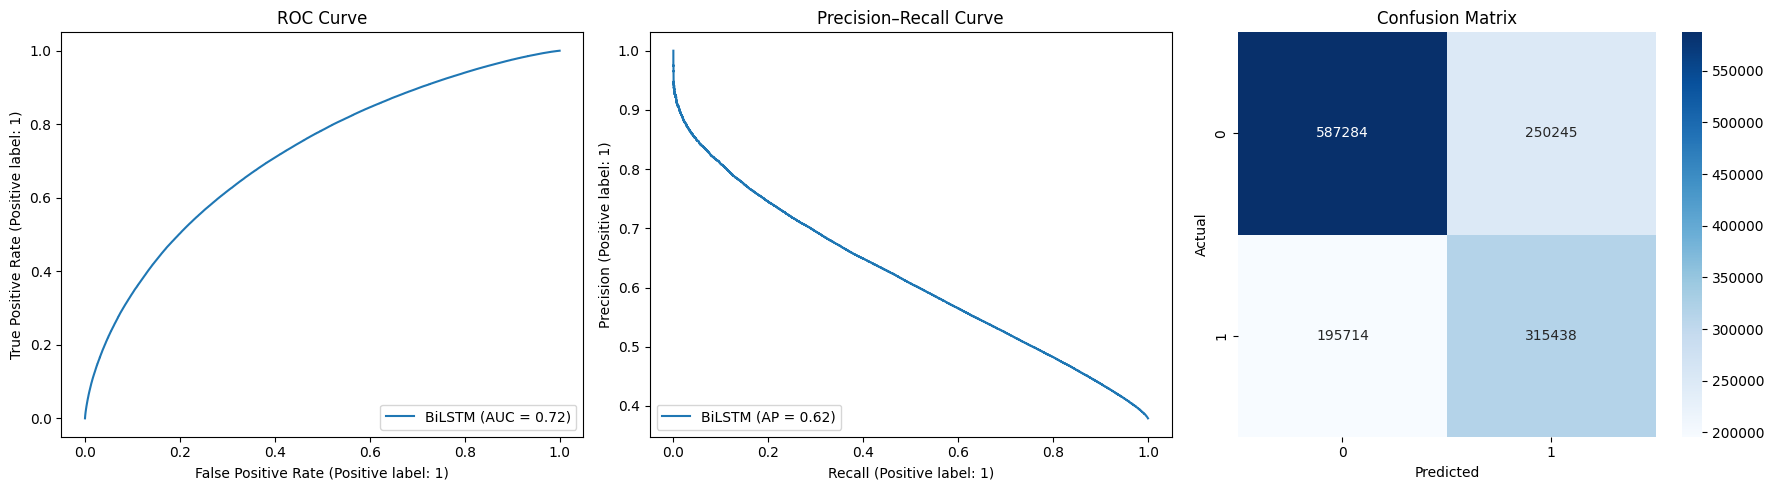

In [26]:
y_true, y_pred, y_prob = predict(model2, test_loader, device)
metrics = evaluate_classification(y_true, y_pred, y_prob)
plot_evaluation_curves(y_true, y_prob)